In [1]:
from utils_VPSDE import * # includes some global functions/variables


Figuring out VPSDE

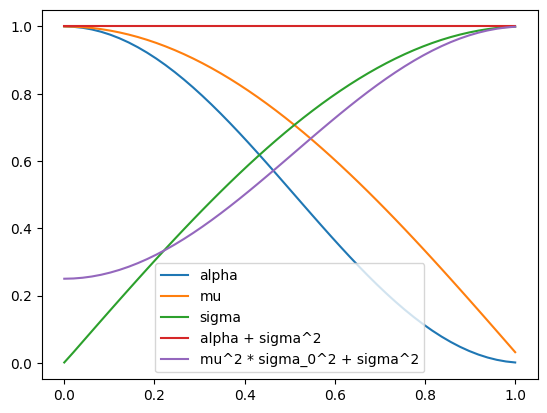

In [2]:
plt.plot(ts, sde.alpha(ts).detach().numpy(), label = 'alpha') 
plt.plot(ts, sde.mu(ts).detach().numpy(), label = 'mu')
plt.plot(ts, sde.sigma(ts).detach().numpy(), label = 'sigma') 
plt.plot(ts, (sde.sigma(ts)**2 + sde.alpha(ts)).detach().numpy(), label = 'alpha + sigma^2')
plt.plot(ts, (sde.mu(ts)**2 * sigma_0**2 + sde.sigma(ts)**2).squeeze(0).detach().numpy(), label = 'mu^2 * sigma_0^2 + sigma^2')
# plt.plot(ts, ((1-sde.alpha(ts))/sde.mu(ts)).detach().numpy(), label = '(1-alpha)/sqrt(alpha)')
# plt.yscale('log')
plt.legend()

In [3]:
def pt(x, t):
    mvn1 = MultivariateNormal(tensor([mu1 * sde.mu(t)]), (sde.mu(t)**2 * sigma_0**2 + sde.sigma(t)**2).reshape((1,1)))
    mvn2 = MultivariateNormal(tensor([mu2 * sde.mu(t)]), (sde.mu(t)**2 * sigma_0**2 + sde.sigma(t)**2).reshape((1,1)))
    return 0.5 * torch.exp(mvn1.log_prob(x)) + 0.5 * torch.exp(mvn2.log_prob(x))

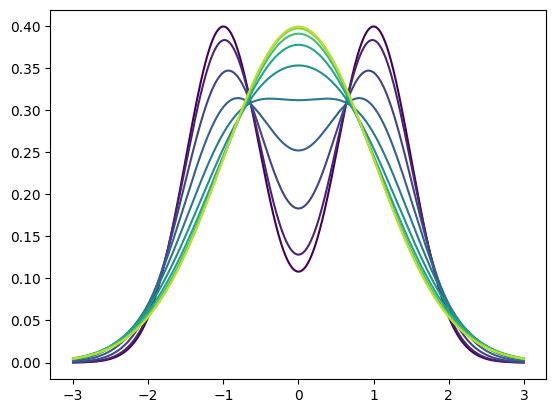

In [4]:
x = torch.linspace(-3, 3, 1000).reshape(-1, 1)
for i, t in enumerate(torch.linspace(0, 1, 10)): 
    plt.plot(x, pt(x, t).detach().numpy(), label = f't = {t}', alpha = 1, color = plt.cm.viridis(i/10))

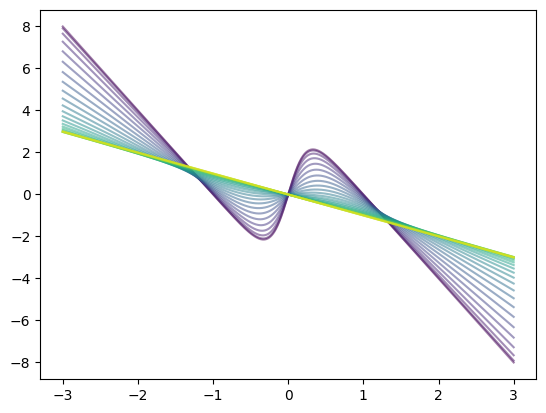

In [5]:
x = torch.linspace(-3, 3, 1000).reshape(-1, 1).requires_grad_(True)
for i, t in enumerate(torch.linspace(0, 1, 25)): 
    plt.plot(x.detach().numpy(), score_pt(x, t).detach().numpy(), label = f't = {t}', alpha = 0.5, color = plt.cm.viridis(i/25))

noising process

notes on VPSDE:
 - sde.alpha returns alpha bar in DDPM
 

In [6]:
n = 10000
dims = 1
xt = torch.zeros(diff_steps, n, dims)
xt[0] =  sample_p0(n).unsqueeze(-1) # torch.ones_like(xt[0])

ts = torch.linspace(0, 1, diff_steps)
dt = ts[1] - ts[0]

for i, t in zip(range(1, diff_steps), ts[1:]):
    xt[i] = (sde.alpha(t)/sde.alpha(t-dt))**0.5* xt[i-1] + (1-(sde.alpha(t)/sde.alpha(t-dt)))**0.5 * torch.randn(n, dims)

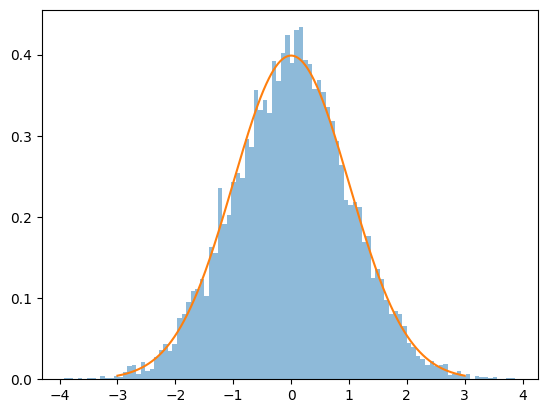

In [7]:
for i in [-1]:
    t = ts[i]
    _ = plt.hist(xt[i].detach().numpy(), bins = 100, density = True, alpha = 0.5)
    plt.plot(x.detach().numpy(), pt(x, t).detach().numpy(), label = f'p(x, t={t})')

In [8]:
# plt.plot(ts, xt.squeeze(-1).std(axis = 1).detach().numpy(), label = 'variance')
# plt.plot(ts, xt.squeeze(-1).mean(axis = 1).detach().numpy(), label = 'mean')

## Unconditional generation

In [9]:
n = 10000 # trials
dims = 1 # dimensionality of data (only works for 1D rn)

xt_bwd = torch.zeros(diff_steps, n, dims)
scores = torch.zeros(diff_steps, n, dims)
xt_bwd[-1] = torch.randn(n, dims)

dt = 1/diff_steps

for i, t in zip(reversed(range(len(ts[1:]))), reversed(ts[1:])):
    alpha_t = sde.alpha(t)/sde.alpha(t-dt)
    beta_t = 1-alpha_t
    score = score_pt(xt_bwd[i+1].clone().detach().requires_grad_(True), t)
    xt_bwd[i] = alpha_t**-0.5 * (xt_bwd[i+1] + beta_t * score) + beta_t.sqrt() * torch.randn(n, 1)
        # SBGM version
        #(1-alpha_t)/(1-sde.alpha(t))**0.5 *  - DDPM version - haven't figured this out yet

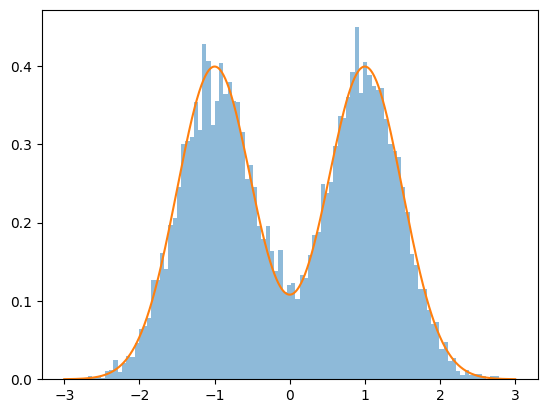

In [10]:
_ = plt.hist(xt_bwd[0].detach().numpy(), bins = 100, density = True, alpha = 0.5)
_ = plt.plot(x.detach().numpy(), pt(x, tensor(0)).detach().numpy(), label = f'p(x, t=0)')

## Conditional generation with Vanilla MC

In [12]:
n = 1000 # trials
dims = 1

xt_bwd = torch.zeros(diff_steps, n, dims)
scores = torch.zeros(diff_steps, n, dims)
xt_bwd[-1] = torch.randn(n, dims)
scores = torch.zeros(diff_steps, n, dims)
guidances = torch.zeros(diff_steps, n, dims)

dt = 1/diff_steps

for i, t in zip(reversed(range(len(ts[1:]))), reversed(ts[1:])):
    alpha_t = sde.alpha(t)/sde.alpha(t-dt)
    beta_t = 1-alpha_t
    score = score_pt(xt_bwd[i+1].clone().detach().requires_grad_(True), t)
    scores[i] = score
    guidance = get_guidance(xt_bwd[i+1].clone().detach().requires_grad_(True), 0.0*torch.ones_like(xt_bwd[i+1]), t, 1000)[0]
    guidances[i] = guidance
    xt_bwd[i] = alpha_t**-0.5 * (xt_bwd[i+1] + beta_t * (score + guidance)) + beta_t.sqrt() * torch.randn(n, 1)


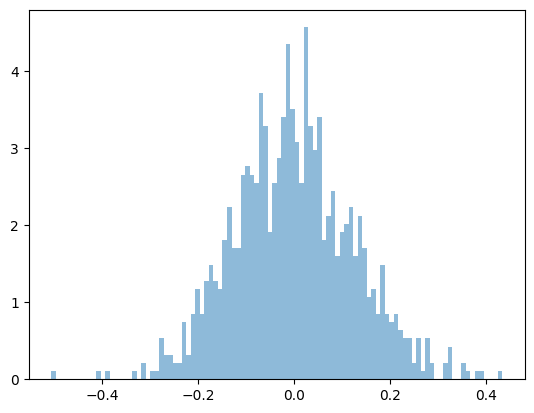

In [13]:
_ = plt.hist(xt_bwd[0].detach().numpy(), bins = 100, density = True, alpha = 0.5)

In [14]:
xt_bwd[0].mean(), xt_bwd[0].std()

(tensor(-0.0008), tensor(0.1249))

## Conditional Generation with IS

In [43]:
n = 100 # trials
dims = 1

xt_bwd = torch.zeros(diff_steps, n, dims)
scores = torch.zeros(diff_steps, n, dims)
xt_bwd[-1] = torch.randn(n, dims)
scores = torch.zeros(diff_steps, n, dims)
guidances = torch.zeros(diff_steps, n, dims)

placeholder_x = tensor([0.0])
placeholder_y = A(placeholder_x)
dt = 1/diff_steps

for i, t in zip(reversed(range(len(ts[1:]))), reversed(ts[1:])):
    alpha_t = sde.alpha(t)/sde.alpha(t-dt)
    beta_t = 1-alpha_t
    score = score_pt(xt_bwd[i+1].clone().detach().requires_grad_(True), t)
    scores[i] = score
    guidance = get_guidance_IS(placeholder_y, xt_bwd[i+1].clone().detach().requires_grad_(True), t, 100)[0]
    guidances[i] = guidance
    xt_bwd[i] = alpha_t**-0.5 * (xt_bwd[i+1] + beta_t * (score + guidance)) + beta_t.sqrt() * torch.randn(n, 1)


estimated mean and variance tensor(-2.3362e-09) tensor(0.1080)


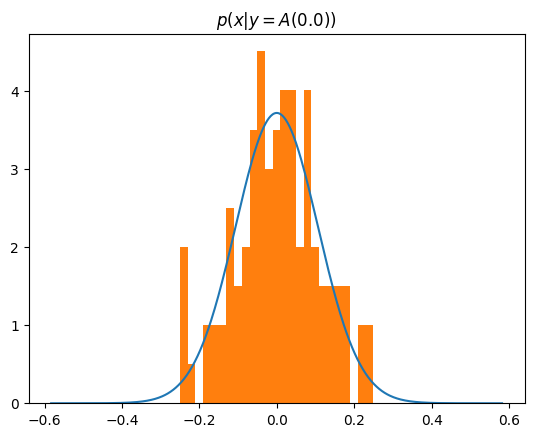

In [44]:
x0_sampled = xt_bwd[0].clone().detach()
sample_mean = x0_sampled.mean()
sample_std = x0_sampled.std()

# estimate the posterior distribution of x_0|y
x = torch.linspace(xt_bwd[0].min() - 3* sample_std, xt_bwd[0].max()+ 3 * sample_std, 500).reshape(-1, 1)
dx = (x[1] - x[0]).item()
log_p0_x = log_pt(x, tensor(0))
log_py_x = log_p_y_given_x(placeholder_y, x)

log_px_y = log_py_x + log_p0_x
px_y = torch.exp(log_px_y)
px_y = px_y / (px_y.sum() * dx)
_ = plt.plot(x.detach().numpy(), px_y.detach().numpy(), label='estimated posterior')
plt.title(r'$p(x|y = A($' + f'{placeholder_x.item()}))')
mean_est = (px_y * x.squeeze()).sum() * dx
std_est = torch.sqrt((px_y * (x.squeeze() - mean_est)**2).sum() * dx)
print('estimated mean and variance', mean_est, std_est)

_ = plt.hist(x0_sampled.detach().numpy(), bins = 25, density = True)

(tensor(0.0020), tensor(0.1110))